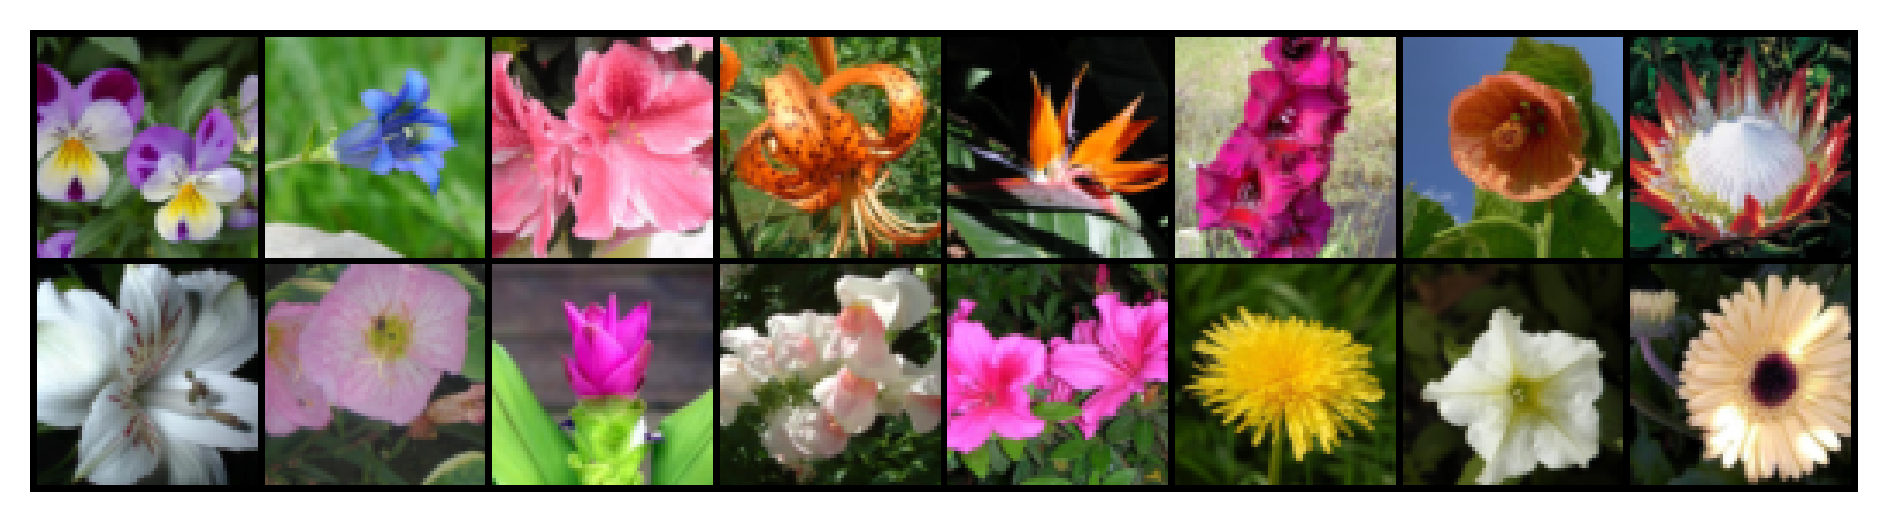

In [1]:
from datasets import load_dataset
from util import transforms

# 下载数据集
dataset = load_dataset("huggan/flowers-102-categories",
    split="train",)
dataset.set_transform(transforms)

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# 可视化数据样本
grid = make_grid(dataset[:16]["input"], 8, 2)
plt.figure(figsize=(8,2),dpi=300)
plt.imshow(grid.numpy().transpose((1,2,0)))
plt.axis("off")
plt.show()

In [ ]:
import torch

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
resolution=64
batch_size=4
train_dataloader=torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True)

In [3]:
# 获取四张干净图像
clean_images=next(iter(train_dataloader))["input"]*2-1
print(clean_images.shape)
nums=clean_images.shape[0]
# 生成张量 noise，其形状与干净图像相同；noise 中的每个值都遵循独立的标准正态分布
noise=torch.randn(clean_images.shape)
print(noise.shape)

torch.Size([2, 3, 64, 64])
torch.Size([2, 3, 64, 64])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


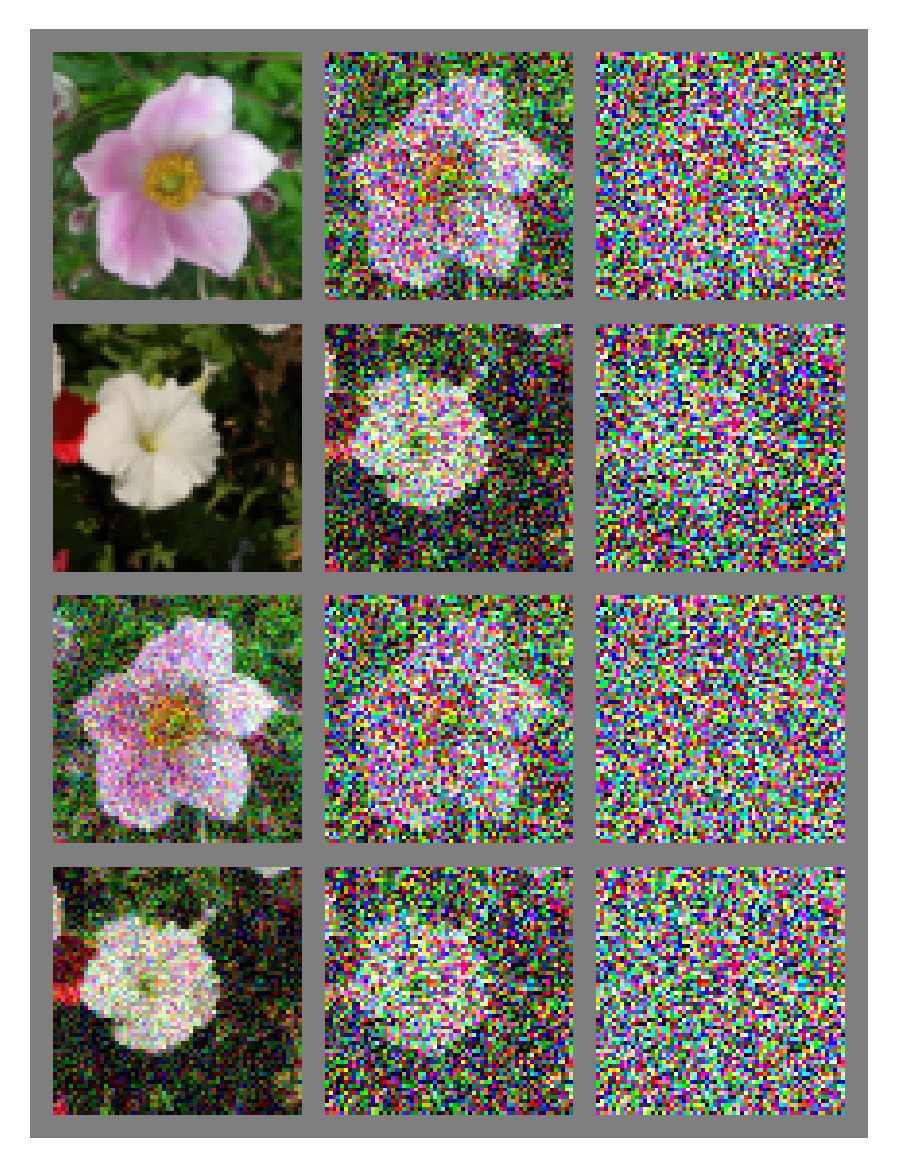

In [ ]:
from util import DDIMScheduler
# 实例化 DDIMScheduler() 类，并设置 1,000 个时间步
noise_scheduler=DDIMScheduler(num_train_timesteps=1000)
allimgs=clean_images
# 查看时间步 200、400、600、800 和 1,000
for step in range(200,1001,200):
    # 创建噪声图像
    timesteps=torch.tensor([step-1]*4).long()
    noisy_images=noise_scheduler.add_noise(clean_images,
                 noise, timesteps)
    # 连接噪声图像与干净图像
    allimgs=torch.cat((allimgs,noisy_images))
# 可视化图像
import torchvision
imgs=torchvision.utils.make_grid(allimgs,4,6)
fig = plt.figure(dpi=300)
plt.imshow((imgs.permute(2,1,0)+1)/2)
plt.axis("off")
plt.show()

In [7]:
from unet_util import UNet

device="cuda" if torch.cuda.is_available() else "cpu"
resolution=64
model=UNet(3,hidden_dims=[128,256,512,1024],
           image_size=resolution).to(device)
num=sum(p.numel() for p in model.parameters())
print("number of parameters: %.2fM" % (num/1e6,))
print(model)

number of parameters: 133.42M
UNet(
  (time_embedding): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (init_conv): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResidualBlock(
        (time_emb_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=128, bias=True)
        )
        (residual_conv): Identity()
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
        (nonlinearity): SiLU()
      )
      (2): Identity()
      (3): Sequential(
        (0): Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
     

In [8]:
from diffusers.optimization import get_scheduler
# 训练 100 个 epoch
num_epochs=100
# 使用 AdamW 优化器
optimizer=torch.optim.AdamW(model.parameters(),lr=0.0001,
    betas=(0.95,0.999),weight_decay=0.00001,eps=1e-8)
# 使用 diffusers 库中的学习率调度器来控制学习率
lr_scheduler=get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=300,
    num_training_steps=(len(train_dataloader) * num_epochs))

In [11]:
for epoch in range(num_epochs):
    model.train()
    tloss = 0
    print(f"start epoch {epoch}")
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["input"].to(device)*2-1
        nums = clean_images.shape[0]
        noise = torch.randn(clean_images.shape).to(device)
        timesteps = torch.randint(0,
                noise_scheduler.num_train_timesteps,
                (nums, ),
                device=device).long()
        # 在训练集中的干净图像上添加噪声
        noisy_images = noise_scheduler.add_noise(clean_images,
                     noise, timesteps)
        # 使用去噪 U-Net 预测噪声
        noise_pred = model(noisy_images, timesteps)["sample"]
        # 将预测的噪声与实际噪声进行比较，计算损失
        loss = torch.nn.functional.l1_loss(noise_pred, noise)
        loss.backward()
        # 调整参数
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        tloss += loss.detach().item()
        if step%100==0:
            print(f"step {step}, average loss {tloss/(step+1)}")

torch.save(model.state_dict(),'files/diffusion.pth')

start epoch 0
step 0, average loss 0.14243611693382263
step 100, average loss 0.14541157556347328
step 200, average loss 0.15199366780878298
step 300, average loss 0.15206907306522427
step 400, average loss 0.15081379881727874
step 500, average loss 0.14764379651588713
step 600, average loss 0.14765912778179677
step 700, average loss 0.14593418701664782
step 800, average loss 0.14764486201405153
step 900, average loss 0.1486718788160038
step 1000, average loss 0.14766458997300097
step 1100, average loss 0.14699367984290235
step 1200, average loss 0.14656055504479426
step 1300, average loss 0.14640241322593675
step 1400, average loss 0.14594423984556987
step 1500, average loss 0.14569272979135953
step 1600, average loss 0.14609557503647055
step 1700, average loss 0.14641364827765255
step 1800, average loss 0.1462515192359752
step 1900, average loss 0.14642182644015705
step 2000, average loss 0.1463457192399021
step 2100, average loss 0.14574470558690916
step 2200, average loss 0.1457499

RuntimeError: Parent directory files does not exist.

In [ ]:
sd=torch.load('files/diffusion.pth', weights_only=False)
model.load_state_dict(sd)
with torch.no_grad():
    # 设置随机种子
    generator = torch.manual_seed()
    # 生成 10 张干净图像
    generated_images,imgs = noise_scheduler.generate(
        model,device,
        num_inference_steps=50,
        generator=generator,
        eta=1.0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp=generated_images["sample"]    
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=300)
# 可视化结果
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'files/diffusion.pth'

In [ ]:
with torch.no_grad():
    generator = torch.manual_seed()
    generated_images,_ = noise_scheduler.generate(
        model,device,
        num_inference_steps=50,
        generator=generator,
        eta=1.0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp=generated_images["sample"]    
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=300)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

In [ ]:
# 保留时间步长 800、600、400、200 和 0
steps=imgs[9::10]
# 从 10 张图像中选择 4 组花卉
imgs20=[]
for j in [1,3,6,9]:
    for i in range(5):
        imgs20.append(steps[i][j])
# 可视化结果
plt.figure(figsize=(10,8),dpi=300)
for i in range(20):
    k=i%5
    ax = plt.subplot(4,5, i + 1)
    plt.imshow(imgs20[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.title(f't={800-200*k}',fontsize=15,c="r")
plt.show()

In [ ]:
from openai import OpenAI
# 替换为实际 OpenAI API 密钥
openai_api_key="your actual OpenAI API key here"
# 实例化 OpenAI() 类
client=OpenAI(api_key=openai_api_key)

# 生成图像
response = client.images.generate(
        model="dall-e-2",
        prompt="an astronaut in a space suit riding a unicorn",
        size="512x512",
        quality="standard",
        n=1,
    )
image_url = response.data[0].url
print(image_url)

In [ ]:
response = client.images.generate(
        model="dall-e-2",
        prompt="a cat in a suit working on a computer",
        size="512x512",
        quality="standard",
        n=1,
    )    
image_url = response.data[0].url
print(image_url)